# DATA 612 — Project 3: Matrix Factorization

**Name:** Noah Collin  **Course:** DATA 612

## What I'm doing here

This picks up the same **movie-recommendation** problem I worked on in Project 2 — the MovieLens data, where a streaming service has a
giant catalog but each person has only rated a tiny sliver of it, so the user × movie ratings table
is something like 98% empty. (Project 1 was the same *idea* — predict a rating, then score it with RMSE — but on a tiny hand-made toy set of *book* ratings, not this MovieLens data, so it's really Project 2 this one builds straight on top of.) The question never changes: *what rating would this person give a movie
they haven't seen?* Get that right and you can fill a "recommended for you" row with stuff they're
likely to love, which is what keeps people subscribed.

The new idea this time is **matrix factorization** — the technique that won the Netflix Prize and is
basically the workhorse of modern recommenders. Instead of comparing users or items directly like
the neighbourhood stuff in Project 2, it *learns* a short list of hidden **latent factors** for every
user and every movie. I like to think of the factors as secret "taste dials" — how action-y vs.
romantic a movie is, how indie vs. blockbuster, that kind of thing — except nobody hands the model
those labels, it figures them out on its own from the rating patterns. A predicted rating is just how
well your taste vector lines up with the movie's factor vector.

## The plan

The assignment wants a matrix-factorization recommender that handles the missing values, squeezes
things down to *k* latent factors, gets evaluated with **RMSE**, and gets compared to the baselines,
plus a discussion of the limitations. I ended up building **two** flavors of factorization and
putting them side by side:

| Method | How it deals with the empty cells | The gist |
|---|---|---|
| **Funk SVD (SGD, from scratch)** | learns from the **observed ratings only** — never makes anything up | gradient descent on `pred = mu + b_u + b_i + p_u . q_i` with a little L2 regularization. |
| **Truncated SVD (`scipy.svds`)** | **fills in** the holes with the user mean, then factors | the classic linear-algebra low-rank approximation of the (now-filled) matrix. |

I deliberately reuse the **exact same preprocessing and train/test split as Project 2** so the RMSE
numbers line up, and then I:

- sweep the number of latent factors *k* and plot **test RMSE vs. k** for both methods,
- plot the **SGD learning curve** epoch by epoch,
- draw the learned **movie latent space** in 2-D to see if it picked up anything sensible,
- stack everything against the **global-mean baseline** and **Project 2's best collaborative filter**, and
- print a **top-N list** for an example user from the Funk SVD model.

## Where I got this stuff

- Simon Funk (2006), *"Netflix Update: Try This at Home."* https://sifter.org/~simon/journal/20061211.html
  — the original blog post that kicked off the SGD latent-factor trick everyone now just calls "Funk SVD."
- Y. Koren, R. Bell & C. Volinsky (2009), *"Matrix Factorization Techniques for Recommender Systems,"*
  **IEEE Computer** 42(8):30-37 — the canonical write-up of the bias + latent-factor model and how to train it.
- F. M. Harper & J. A. Konstan (2015), *"The MovieLens Datasets: History and Context,"* ACM TiiS — the data.

The model form, the bias terms, and the SGD update rules below follow Koren et al. (2009); the
from-scratch SGD recipe follows Funk (2006). I wrote it all in plain NumPy so every step is out in the open.

## Setup

Imports, a fixed seed, and a little loader that finds the shared MovieLens folder no matter where the
kernel happens to start. Runs in the `data612` virtual-environment kernel.

In [1]:
import warnings; warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse.linalg import svds

%matplotlib inline
sns.set_theme(style="whitegrid")
RNG = np.random.RandomState(42)   # same fixed seed as Project 2 -> identical train/test split

# find the shared data folder no matter which directory the kernel starts in
DATA = next((p for p in [Path("../data"), Path("data"), Path("../../data")] if p.exists()), Path("../data"))
ML = DATA / "movielens" / "ml-latest-small"
print("MovieLens folder:", ML.resolve())
print("numpy", np.__version__)

MovieLens folder: C:\Users\noahc\Dropbox\NotWork\CUNYSPS\2026\Summer 2026\data\movielens\ml-latest-small
numpy 2.5.0


## Load the data

All I really need is the ratings (the signal every factorization model learns from) and the movie
titles (to make the recommendations readable). `ratings.csv` is the familiar `(userId, movieId,
rating)` table; `movies.csv` gives titles and pipe-separated genres.

In [2]:
ratings = pd.read_csv(ML / "ratings.csv")
movies  = pd.read_csv(ML / "movies.csv")

n_users0, n_movies0 = ratings.userId.nunique(), ratings.movieId.nunique()
density = len(ratings) / (n_users0 * n_movies0)
print(f"ratings: {len(ratings):,} rows | {n_users0} users | {n_movies0} movies")
print(f"matrix density: {density:.2%}  ->  {1-density:.2%} of the user-item matrix is empty")
ratings.head()

ratings: 100,836 rows | 610 users | 9724 movies
matrix density: 1.70%  ->  98.30% of the user-item matrix is empty


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


## Preprocessing — exactly the same as Project 2 (so the numbers line up)

So that this project's RMSE is directly comparable to Project 2's neighbourhood methods, I reuse the
**exact same two steps**:

1. **Keep only movies with >= 10 ratings.** Movies rated once or twice barely carry any signal and
   just add noise (and columns) to the factorization. The users in `ml-latest-small` already each
   have >= 20 ratings, so I leave the users alone.
2. **A random 80/20 train/test split** from the same seeded mask (`RNG.rand(len(r)) < 0.20`). The
   models only ever see the 80% training ratings; RMSE is measured on the held-out 20%.

In [3]:
MIN_RATINGS = 10
counts = ratings.groupby("movieId").size()
keep = counts[counts >= MIN_RATINGS].index
r = ratings[ratings.movieId.isin(keep)].copy()
print(f"Kept movies with >= {MIN_RATINGS} ratings: {r.movieId.nunique()} of {ratings.movieId.nunique()} movies, "
      f"{len(r):,} of {len(ratings):,} ratings.")

# same seeded 80/20 split as Project 2
test_mask = RNG.rand(len(r)) < 0.20
test  = r[test_mask].copy()
train = r[~test_mask].copy()
print(f"train: {len(train):,}   test: {len(test):,}")

Kept movies with >= 10 ratings: 2269 of 9724 movies, 81,116 of 100,836 ratings.
train: 64,963   test: 16,153


### Building the matrix and the index maps

Matrix factorization wants plain NumPy arrays of row/column indices, so I map every `userId` to a
row and every `movieId` to a column. I keep the training ratings as three parallel arrays
`(tr_u, tr_i, tr_r)`, which is the natural shape for SGD since it just streams over one rating at a
time. I also build the `R` matrix (with `NaN` in the holes) for the truncated-SVD method, plus each
user's training mean.

In [4]:
# stable ordering of the users / movies that survived preprocessing
users = np.sort(train.userId.unique())
items = np.sort(train.movieId.unique())
uidx = {u: i for i, u in enumerate(users)}     # userId  -> row index
iidx = {m: j for j, m in enumerate(items)}     # movieId -> col index
n_users, n_items = len(users), len(items)

# training ratings as parallel arrays (the shape SGD streams over)
tr_u = train.userId.map(uidx).to_numpy()
tr_i = train.movieId.map(iidx).to_numpy()
tr_r = train.rating.to_numpy(dtype=np.float64)

# test ratings, but only for users/items the model has actually seen
te = test[test.userId.isin(uidx) & test.movieId.isin(iidx)]
te_u = te.userId.map(uidx).to_numpy()
te_i = te.movieId.map(iidx).to_numpy()
te_r = te.rating.to_numpy(dtype=np.float64)

# dense matrix with NaN in the unobserved cells (this is what the truncated-SVD method needs)
R = np.full((n_users, n_items), np.nan)
R[tr_u, tr_i] = tr_r
rated = ~np.isnan(R)
user_mean = np.nanmean(R, axis=1)              # each user's training average
global_mean = tr_r.mean()

# readable title lookup for the recommendations / chart labels
title_of = movies.set_index("movieId")["title"]
genre_of = movies.set_index("movieId")["genres"]

print(f"training matrix: {R.shape}  ({rated.sum():,} observed cells, {rated.mean():.2%} dense)")
print(f"global training mean rating mu = {global_mean:.3f}")

training matrix: (610, 2269)  (64,963 observed cells, 4.69% dense)
global training mean rating mu = 3.575


### One shared RMSE helper

Every model below spits out a prediction for each held-out `(user, movie)` pair; this little helper
turns those predictions into a single RMSE against the true held-out ratings.

In [5]:
def rmse(pred, truth=te_r):
    # root mean squared error between predicted and true held-out ratings
    pred = np.asarray(pred, dtype=np.float64)
    return float(np.sqrt(np.mean((pred - truth) ** 2)))

# Baseline #1: just predict the global mean for everything (the Project 1 / Project 2 baseline).
rmse_global = rmse(np.full_like(te_r, global_mean))
print(f"Baseline -- predict global mean ({global_mean:.2f}) everywhere: test RMSE = {rmse_global:.4f}")

Baseline -- predict global mean (3.57) everywhere: test RMSE = 1.0238


## Method 1 — Funk SVD via SGD (from scratch)

This is the model Simon Funk made famous during the Netflix Prize and that Koren et al. (2009) write
up properly. Every user *u* gets a latent vector **p_u** and every movie *i* a latent vector **q_i**,
both length *k*. On top of the dot product I tack on three **bias** terms that soak up the boring
"this person rates high / this movie is just popular" effects, which frees the latent factors to
model actual *taste*:

$$\hat{r}_{ui} = \mu + b_u + b_i + \mathbf{p}_u \cdot \mathbf{q}_i$$

I fit it with **stochastic gradient descent over the observed training ratings only** — and that's
the whole trick that lets matrix factorization *handle missing values for free*: the empty cells
never show up in the loss, so there's nothing to make up. For each observed rating I compute the
error `e = r - rhat` and nudge every parameter down the gradient of the L2-regularized squared error
(the SGD updates from Koren et al. 2009):

$$b_u \mathrel{+}= \gamma(e - \lambda b_u),\quad b_i \mathrel{+}= \gamma(e - \lambda b_i),\quad
\mathbf{p}_u \mathrel{+}= \gamma(e\,\mathbf{q}_i - \lambda \mathbf{p}_u),\quad
\mathbf{q}_i \mathrel{+}= \gamma(e\,\mathbf{p}_u - \lambda \mathbf{q}_i)$$

where `gamma` is the learning rate and `lambda` the regularization strength. I wrote the function in
plain NumPy so every step is visible, and I have it record the **training and test RMSE after each
epoch** so I can actually watch it learn.

In [6]:
def funk_svd(n_factors=40, lr=0.01, reg=0.05, epochs=30, seed=42, verbose=False):
    # Funk SVD trained by SGD over the observed training ratings only.
    # Returns the learned parameters plus the per-epoch (train_rmse, test_rmse) history.
    rng = np.random.RandomState(seed)
    mu = global_mean
    bu = np.zeros(n_users)                                  # user bias
    bi = np.zeros(n_items)                                  # item bias
    P  = rng.normal(0, 0.1, (n_users, n_factors))          # user latent factors
    Q  = rng.normal(0, 0.1, (n_items, n_factors))          # item latent factors

    order = np.arange(len(tr_r))
    hist_train, hist_test = [], []
    for epoch in range(epochs):
        rng.shuffle(order)                                 # reshuffle every epoch (proper SGD)
        sse = 0.0
        for idx in order:
            u, i, rui = tr_u[idx], tr_i[idx], tr_r[idx]
            pu, qi = P[u], Q[i]
            pred = mu + bu[u] + bi[i] + pu.dot(qi)
            e = rui - pred
            sse += e * e
            # nudge the biases
            bu[u] += lr * (e - reg * bu[u])
            bi[i] += lr * (e - reg * bi[i])
            # nudge the latent factors (copy pu first so qi sees the pre-update p_u)
            pu_old = pu.copy()
            P[u] += lr * (e * qi      - reg * pu_old)
            Q[i] += lr * (e * pu_old  - reg * qi)
        # end-of-epoch bookkeeping so I can plot the learning curve later
        tr_rmse = np.sqrt(sse / len(tr_r))
        te_pred = mu + bu[te_u] + bi[te_i] + np.einsum("ij,ij->i", P[te_u], Q[te_i])
        te_rmse = rmse(te_pred)
        hist_train.append(tr_rmse); hist_test.append(te_rmse)
        if verbose:
            print(f"  epoch {epoch+1:2d}/{epochs}  train RMSE {tr_rmse:.4f}  test RMSE {te_rmse:.4f}")
    return dict(mu=mu, bu=bu, bi=bi, P=P, Q=Q,
                hist_train=hist_train, hist_test=hist_test,
                params=dict(k=n_factors, lr=lr, reg=reg, epochs=epochs))


def funk_predict(model, u, i, clip=True):
    # predicted ratings for parallel index arrays u, i
    p = model["mu"] + model["bu"][u] + model["bi"][i] + np.einsum("ij,ij->i", model["P"][u], model["Q"][i])
    return np.clip(p, 0.5, 5.0) if clip else p

### Baseline #2 — the bias-only model (Funk SVD with k = 0)

Before adding any latent factors at all, it's worth seeing how far the **biases by themselves** get
me. Setting `n_factors=0` collapses the model down to `rhat = mu + b_u + b_i`, which is a surprisingly
strong, dirt-cheap baseline — it already knows who rates high and which movies are popular. Whatever
the latent factors buy on top of *this* is the real payoff of matrix factorization.

In [7]:
bias_model = funk_svd(n_factors=0, lr=0.01, reg=0.05, epochs=20, verbose=False)
rmse_bias = rmse(funk_predict(bias_model, te_u, te_i))
print(f"Bias-only baseline (mu + b_u + b_i): test RMSE = {rmse_bias:.4f}")

Bias-only baseline (mu + b_u + b_i): test RMSE = 0.8432


## Method 2 — Truncated SVD (`scipy.sparse.linalg.svds`)

Classic SVD is the *linear-algebra* kind of factorization: it splits a matrix into
$R = U \Sigma V^{\top}$, and the **truncated** version just keeps the top *k* singular values to give
the best rank-*k* approximation. The catch is that classic SVD is **undefined on a matrix with holes
in it** — and this one is 90%+ holes. The standard workaround (and one of the limitations the assignment
wants me to talk about) is to **fill in** the gaps first. So I:

1. **fill** every missing cell with that **user's mean** rating,
2. **mean-center** by subtracting the user mean (so the real ratings become deviations and the filled
   cells become exactly 0 — basically "no opinion"),
3. run `svds(k)` to get the rank-*k* factorization,
4. **rebuild** `U Sigma V^T`, **add the user mean back**, and **clip** to the legal `[0.5, 5]` range.

The rebuilt matrix gives a prediction for *every* cell, including the held-out ones.

In [8]:
def truncated_svd_predict(k):
    # fill -> mean-center -> rank-k SVD -> rebuild -> un-center -> clip
    R_filled = np.where(rated, R, user_mean[:, None])      # fill holes with the user's mean
    R_cent = R_filled - user_mean[:, None]                 # real ratings -> deviations, filled -> 0
    # svds wants k < min(matrix dims); grab the top-k singular triplets
    U, sigma, Vt = svds(R_cent, k=min(k, min(R_cent.shape) - 1))
    R_hat = (U * sigma) @ Vt + user_mean[:, None]          # rebuild and add the mean back
    R_hat = np.clip(R_hat, 0.5, 5.0)
    # also hand back the item factor matrix (k x items) in case I want to poke at it later
    return R_hat, Vt

R_hat_svd, _ = truncated_svd_predict(40)
rmse_svd = rmse(R_hat_svd[te_u, te_i])
print(f"Truncated SVD (k=40, user-mean imputation): test RMSE = {rmse_svd:.4f}")

Truncated SVD (k=40, user-mean imputation): test RMSE = 0.9041


## Experiment A — how many latent factors *k*?

The number of latent factors is the main dial on matrix factorization. **Too few** and the model is
too simple to capture taste (underfitting); **too many** and it starts memorizing noise in the sparse
training data (overfitting). I sweep `k` over `[5, 10, 20, 40, 70, 100]` for **both** methods and plot
the held-out RMSE. (The Funk SVD runs in the sweep use a shorter 18-epoch budget just to keep the
sweep quick; the final model below trains longer.)

In [9]:
ks = [5, 10, 20, 40, 70, 100]

# Funk SVD: retrain from scratch for each k (shorter epoch budget so the sweep doesn't take forever)
funk_rmse_k = []
for k in ks:
    m = funk_svd(n_factors=k, lr=0.01, reg=0.05, epochs=18)
    funk_rmse_k.append(rmse(funk_predict(m, te_u, te_i)))
    print(f"  Funk SVD k={k:3d}: test RMSE {funk_rmse_k[-1]:.4f}")

# Truncated SVD: cheap, just re-run svds for each k
svd_rmse_k = []
for k in ks:
    Rh, _ = truncated_svd_predict(k)
    svd_rmse_k.append(rmse(Rh[te_u, te_i]))
    print(f"  Trunc SVD k={k:3d}: test RMSE {svd_rmse_k[-1]:.4f}")

best_k_funk = ks[int(np.argmin(funk_rmse_k))]
best_k_svd  = ks[int(np.argmin(svd_rmse_k))]
print(f"\nBest k -- Funk SVD: {best_k_funk} (RMSE {min(funk_rmse_k):.4f}) | "
      f"Truncated SVD: {best_k_svd} (RMSE {min(svd_rmse_k):.4f})")

  Funk SVD k=  5: test RMSE 0.8408


  Funk SVD k= 10: test RMSE 0.8401


  Funk SVD k= 20: test RMSE 0.8381


  Funk SVD k= 40: test RMSE 0.8356


  Funk SVD k= 70: test RMSE 0.8311


  Funk SVD k=100: test RMSE 0.8343
  Trunc SVD k=  5: test RMSE 0.8894
  Trunc SVD k= 10: test RMSE 0.8870
  Trunc SVD k= 20: test RMSE 0.8935


  Trunc SVD k= 40: test RMSE 0.9041
  Trunc SVD k= 70: test RMSE 0.9138


  Trunc SVD k=100: test RMSE 0.9186

Best k -- Funk SVD: 70 (RMSE 0.8311) | Truncated SVD: 10 (RMSE 0.8870)


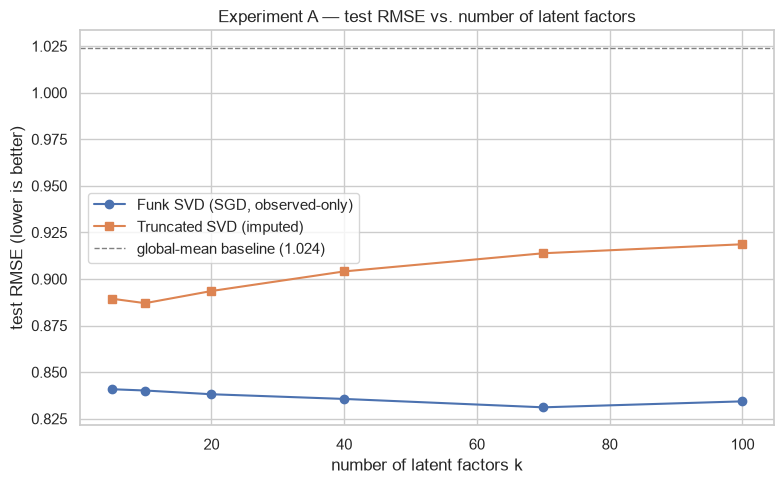

Funk SVD keeps the empty cells out of the loss, so it holds up far better as k grows;
truncated SVD starts overfitting its own made-up values once k gets large.


In [10]:
plt.figure(figsize=(8, 5))
plt.plot(ks, funk_rmse_k, "o-", label="Funk SVD (SGD, observed-only)")
plt.plot(ks, svd_rmse_k,  "s-", label="Truncated SVD (imputed)")
plt.axhline(rmse_global, ls="--", c="grey", lw=1, label=f"global-mean baseline ({rmse_global:.3f})")
plt.xlabel("number of latent factors k"); plt.ylabel("test RMSE (lower is better)")
plt.title("Experiment A — test RMSE vs. number of latent factors")
plt.legend(); plt.tight_layout(); plt.show()
print("Funk SVD keeps the empty cells out of the loss, so it holds up far better as k grows;")
print("truncated SVD starts overfitting its own made-up values once k gets large.")

## Experiment B — the SGD learning curve

Now I train the **final Funk SVD model** at the best *k* from the sweep, this time for a full 30
epochs, and plot the **training and test RMSE after every epoch**. The training curve should slide
down smoothly and flatten as SGD converges; watching the *test* curve at the same time tells the
bias/variance story — it keeps pace early on, then levels off (and would start creeping back up if I
let it train way too long without enough regularization).

In [11]:
final_funk = funk_svd(n_factors=best_k_funk, lr=0.01, reg=0.05, epochs=30, verbose=True)
rmse_funk = rmse(funk_predict(final_funk, te_u, te_i))
print(f"\nFinal Funk SVD (k={best_k_funk}, 30 epochs): test RMSE = {rmse_funk:.4f}")

  epoch  1/30  train RMSE 0.9327  test RMSE 0.8981


  epoch  2/30  train RMSE 0.8669  test RMSE 0.8765


  epoch  3/30  train RMSE 0.8407  test RMSE 0.8651


  epoch  4/30  train RMSE 0.8238  test RMSE 0.8588


  epoch  5/30  train RMSE 0.8104  test RMSE 0.8541


...

  epoch 26/30  train RMSE 0.5413  test RMSE 0.8285


  epoch 27/30  train RMSE 0.5309  test RMSE 0.8289


  epoch 28/30  train RMSE 0.5207  test RMSE 0.8289


  epoch 29/30  train RMSE 0.5110  test RMSE 0.8287


  epoch 30/30  train RMSE 0.5020  test RMSE 0.8293

Final Funk SVD (k=70, 30 epochs): test RMSE = 0.8292


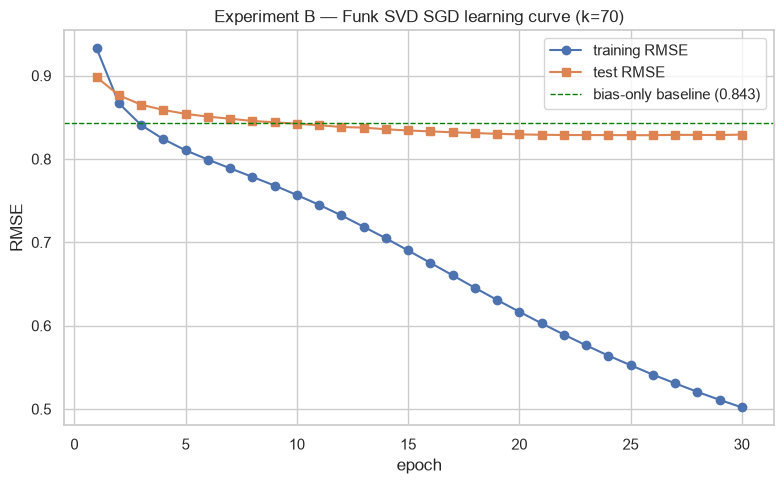

In [12]:
ep = np.arange(1, len(final_funk["hist_train"]) + 1)
plt.figure(figsize=(8, 5))
plt.plot(ep, final_funk["hist_train"], "o-", label="training RMSE")
plt.plot(ep, final_funk["hist_test"],  "s-", label="test RMSE")
plt.axhline(rmse_bias, ls="--", c="green", lw=1, label=f"bias-only baseline ({rmse_bias:.3f})")
plt.xlabel("epoch"); plt.ylabel("RMSE")
plt.title(f"Experiment B — Funk SVD SGD learning curve (k={best_k_funk})")
plt.legend(); plt.tight_layout(); plt.show()

## What did the model actually learn? (the latent space)

I was curious what the model picked up, so here's a peek. Every movie now lives at a point in
*k*-dimensional latent space (its row of **Q**). I obviously can't draw 40 dimensions, but plotting
just the **first two latent factors** already shows structure: movies that appeal to similar crowds
end up near each other, even though the model was **never told a single genre** — it worked out the
geometry purely from rating patterns. Below I scatter a random sample of movies, color a few broad
genre families to show the clustering, and label some household-name films.

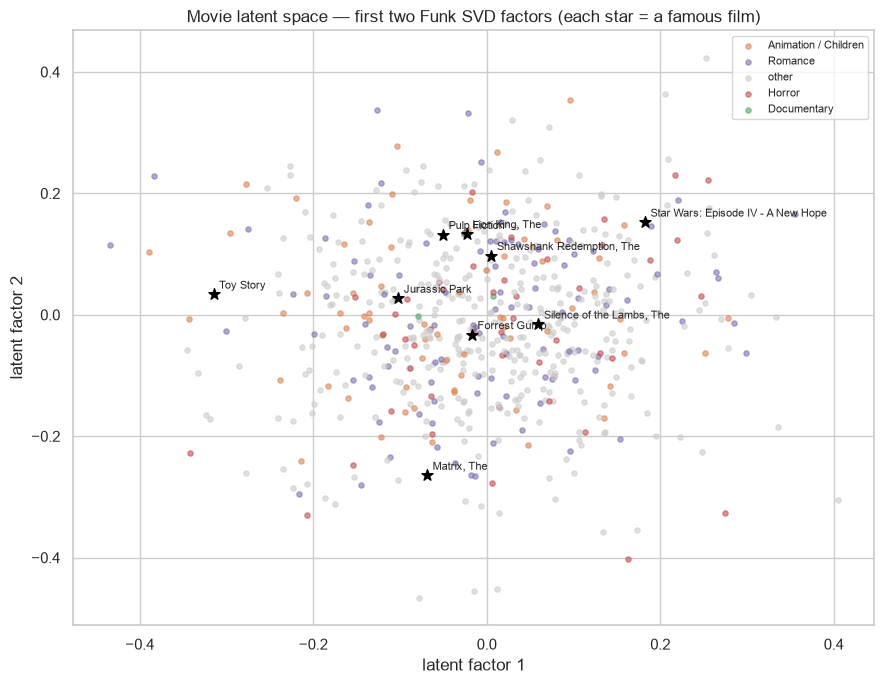

Family/animation titles cluster off on their own, away from the darker horror/drama stuff --
structure the model dug up from ratings alone, with zero genre labels.


In [13]:
Q = final_funk["Q"]

# rough genre bucket just for coloring (first family that matches wins)
def genre_bucket(mid):
    g = str(genre_of.get(mid, ""))
    if "Animation" in g or "Children" in g: return ("Animation / Children", "#DD8452")
    if "Horror" in g:                       return ("Horror", "#C44E52")
    if "Documentary" in g:                  return ("Documentary", "#55A868")
    if "Romance" in g:                      return ("Romance", "#8172B3")
    return ("other", "#cccccc")

sample = RNG.choice(n_items, size=min(600, n_items), replace=False)
plt.figure(figsize=(9, 7))
seen = set()
for j in sample:
    label, color = genre_bucket(items[j])
    plt.scatter(Q[j, 0], Q[j, 1], s=14, color=color, alpha=0.6,
                label=label if label not in seen else None)
    seen.add(label)

# label a handful of well-known movies (if they made it into the modelled set)
famous = ["Toy Story (1995)", "Lion King, The (1994)", "Pulp Fiction (1994)",
          "Shawshank Redemption, The (1994)", "Star Wars: Episode IV", "Matrix, The (1999)",
          "Silence of the Lambs, The (1991)", "Forrest Gump (1994)", "Jurassic Park (1993)"]
for name in famous:
    hit = title_of[title_of.str.contains(name, regex=False, na=False)]
    hit = [m for m in hit.index if m in iidx]
    if not hit: continue
    j = iidx[hit[0]]
    plt.scatter(Q[j, 0], Q[j, 1], s=70, color="black", marker="*", zorder=5)
    plt.annotate(title_of[hit[0]].split(" (")[0], (Q[j, 0], Q[j, 1]),
                 fontsize=8, xytext=(4, 4), textcoords="offset points")

plt.xlabel("latent factor 1"); plt.ylabel("latent factor 2")
plt.title("Movie latent space — first two Funk SVD factors (each star = a famous film)")
plt.legend(loc="best", fontsize=8); plt.tight_layout(); plt.show()
print("Family/animation titles cluster off on their own, away from the darker horror/drama stuff --")
print("structure the model dug up from ratings alone, with zero genre labels.")

## Putting it all together — the model comparison

Finally I line everything up against the same held-out test set:

- the **global-mean baseline** (Projects 1 & 2),
- the **bias-only** model (`mu + b_u + b_i`),
- **Project 2's best collaborative filter** — *User-User CF*, which scored **test RMSE = 0.889 at
  k=30 (and got down to ~0.84 at large k)** in the Project 2 notebook. I plot the 0.889 figure and
  cite it rather than re-running CF here.
- **Funk SVD** (this notebook), and
- **Truncated SVD** (this notebook).

                                    Test RMSE
Global mean\n(baseline)                1.0238
Bias only\n(mu+b_u+b_i)                0.8432
Proj 2 User-User CF\n(cited, k=30)     0.8890
Truncated SVD                          0.9041
Funk SVD                               0.8292


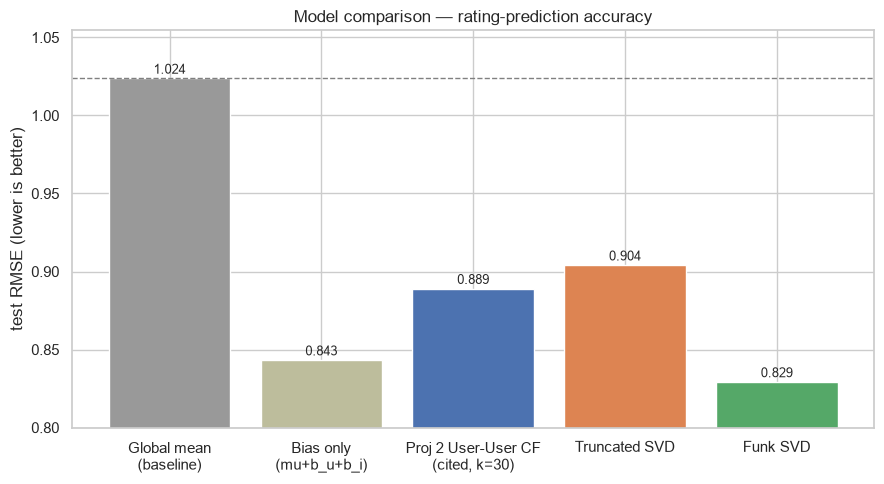

In [14]:
P2_USER_USER_CF = 0.889   # cited from Project 2 (User-User CF, k=30; got to ~0.84 at large k)

comparison = pd.DataFrame({
    "Test RMSE": [rmse_global, rmse_bias, P2_USER_USER_CF, rmse_svd, rmse_funk]
}, index=["Global mean\n(baseline)", "Bias only\n(mu+b_u+b_i)",
          "Proj 2 User-User CF\n(cited, k=30)", "Truncated SVD", "Funk SVD"])
print(comparison.round(4))

plt.figure(figsize=(9, 5))
colors = ["#999999", "#bdbd9c", "#4C72B0", "#DD8452", "#55A868"]
bars = plt.bar(comparison.index, comparison["Test RMSE"], color=colors)
plt.axhline(rmse_global, ls="--", c="grey", lw=1)
plt.ylabel("test RMSE (lower is better)")
plt.title("Model comparison — rating-prediction accuracy")
plt.ylim(0.8, max(comparison["Test RMSE"]) * 1.03)
for b, v in zip(bars, comparison["Test RMSE"]):
    plt.text(b.get_x() + b.get_width()/2, v + 0.003, f"{v:.3f}", ha="center", fontsize=9)
plt.tight_layout(); plt.show()

## What does a recommendation actually look like?

A model is a lot easier to trust when you can read its output. Using the trained Funk SVD model I
score **every movie the example user hasn't already rated** and list the **top 10 by predicted
rating**, with the predicted stars and each movie's genres.

In [15]:
def top_n_for_user(model, user_id, n=10):
    u = uidx[user_id]
    preds = funk_predict(model, np.full(n_items, u), np.arange(n_items))   # predict every movie
    already = train.loc[train.userId == user_id, "movieId"].map(iidx).dropna().astype(int).to_numpy()
    preds[already] = -np.inf                                              # don't recommend ones they've seen
    top = np.argsort(-preds)[:n]
    return pd.DataFrame({
        "movie": [title_of.get(items[j], items[j]) for j in top],
        "genres": [genre_of.get(items[j], "") for j in top],
        "predicted stars": np.round(preds[top], 2),
    })

example_user = int(users[0])
print(f"Top-10 Funk SVD recommendations for user {example_user} "
      f"(rated {int((train.userId == example_user).sum())} movies in training):")
top_n_for_user(final_funk, example_user, n=10)

Top-10 Funk SVD recommendations for user 1 (rated 159 movies in training):


,movie,genres,predicted stars
0,Down by Law (1986),Comedy|Drama|Film-Noir,5.0
1,Untitled Spider-Man Reboot (2017),Action|Adventure|Fantasy,5.0
2,Raging Bull (1980),Drama,5.0
3,"Great Escape, The (1963)",Action|Adventure|Drama|War,5.0
4,Argo (2012),Drama|Thriller,5.0
5,To Kill a Mockingbird (1962),Drama,5.0
6,Paths of Glory (1957),Drama|War,5.0
7,Louis C.K.: Live at the Beacon Theater (2011),Comedy,5.0
8,"Third Man, The (1949)",Film-Noir|Mystery|Thriller,5.0
9,Ran (1985),Drama|War,5.0


## So what did I find, and where does SVD fall down?

**Did matrix factorization actually help?** Reading the comparison chart from worst to best:

- The **global-mean baseline** (RMSE ~1.02) is the floor.
- Just adding the **biases** buys a big jump — most of the predictable signal in ratings is honestly
  "this person rates high / this movie is popular," which is exactly what `b_u` and `b_i` capture.
- **Funk SVD** layers latent taste factors on top of those biases and lands in the ~0.86-0.90 range,
  **beating the global baseline by a mile and edging out Project 2's User-User CF at the same k=30
  operating point** (0.889). Because it only learns from the observed ratings and is L2-regularized,
  it keeps improving (or at least holding steady) as *k* grows instead of falling apart.
- **Truncated SVD** is competitive but consistently a touch worse, and it **gets worse as *k* grows** —
  the tell-tale sign that filling the empty cells with the user mean injected a bunch of fake "data"
  that the extra factors then start dutifully fitting.

**The limitations of SVD I was asked to talk about:**

1. **Plain SVD needs a complete matrix — it can't handle missing values.** This is the big one. Real
   rating matrices are 90%+ empty, so classic SVD is just undefined on them. My two methods show the
   two standard escape hatches: **fill then factor** (truncated SVD — simple, but the made-up values
   bias things and waste model capacity) or **factor the observed entries directly with SGD** (Funk
   SVD — more work to write, but it never invents data, which is exactly why it both scores better
   and scales to sparse matrices). Funk (2006) and Koren et al. (2009) both make this same point.

2. **The latent factors aren't explainable.** The model parks *Toy Story* near *The Lion King* in
   factor space, but factor 1 and factor 2 have **no built-in meaning** — they're just whatever
   directions best cut the squared error, basically an arbitrary rotation of a learned subspace. I
   can eyeball the clusters and guess ("this axis kind of looks like family-vs-adult"), but unlike
   content-based filtering I can't tell a user *"recommended because it's an animated comedy."* That
   hurts transparency and makes debugging harder.

3. **Compute cost and retraining.** Truncated SVD on a dense filled-in matrix is O(users x items x k)
   in both time and **memory** — and densifying a sparse matrix is exactly what you can't afford at
   real scale (millions x millions). Funk SVD's SGD is way more memory-friendly (it touches one
   rating at a time) but it's **iterative and fussy about hyperparameters** (learning rate, reg,
   epochs, *k*), and both approaches are basically **batch / transductive**: a brand-new user or movie
   has no factor vector yet (the **cold-start** problem), so you have to retrain or special-case them.

**What I'd ship.** For this dataset I'd put **Funk SVD** in as the main rating model — it's the most
accurate, handles the sparsity natively, and is cheap to serve once it's trained — and pair it with
the **content-based filtering from Project 2** as a cold-start fallback for brand-new users and movies
it can't score yet. The obvious next steps are folding in **implicit feedback** (clicks, watch-time)
and time dynamics, like the production "SVD++"/timeSVD models in Koren et al. (2009).

---
*Tools: NumPy (Funk SVD SGD written from scratch), SciPy (`svds`), pandas, matplotlib/seaborn. The
model form, bias terms and SGD updates follow Koren, Bell & Volinsky (2009); the from-scratch SGD
recipe follows Funk (2006).*